# PCLab#1 - Group 4 - Claas Boumans, Giuliano Ciaramella, Theodor Nissen-Meyer

In [2]:
#-----------Import Libraries-----------#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.figure_factory as ff
from scipy.optimize import minimize     # for efficient frontier minimization process

In [3]:
# Import the csv file
df = pd.read_csv('Data_PCLab1_Stock.csv', parse_dates=['Date'])

In [4]:
# checking current index
print(df.index)

RangeIndex(start=0, stop=2159, step=1)


In [5]:
# Inspect the shape
df.shape

(2159, 10)

In [6]:
# Print the first and last date in the sample
print(f'Starting date:  {min(df['Date']).date()}\nLast date:      {max(df['Date']).date()}')

Starting date:  2012-01-12
Last date:      2020-08-11


In [7]:
# Inspect columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2159 entries, 0 to 2158
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2159 non-null   datetime64[ns]
 1   AAPL    2159 non-null   float64       
 2   BA      2159 non-null   float64       
 3   T       2159 non-null   float64       
 4   MGM     2159 non-null   float64       
 5   AMZN    2159 non-null   float64       
 6   IBM     2159 non-null   float64       
 7   TSLA    2159 non-null   float64       
 8   GOOG    2159 non-null   float64       
 9   sp500   2159 non-null   float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 168.8 KB


In [8]:
# Summary statistics
df.describe()

,Date,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
count,2159,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000
mean,2016-04-27 17:57:49.939787008,140.819823,189.942700,35.162899,23.105743,915.665665,161.853001,259.600815,783.712512,2218.749554
min,2012-01-12 00:00:00,55.790001,67.239998,26.770000,7.140000,175.929993,94.769997,22.790001,278.481171,1278.040039
25%,2014-03-08 12:00:00,89.165714,124.015000,33.040001,18.545000,316.490005,142.769997,184.595001,527.214416,1847.984985
50%,2016-04-28 00:00:00,116.599998,142.419998,34.930000,23.780001,676.010010,156.949997,231.960007,737.599976,2106.629883
75%,2018-06-19 12:00:00,175.019997,297.044998,37.419998,28.430000,1593.645019,185.974998,307.350006,1079.744995,2705.810059
max,2020-08-11 00:00:00,455.609985,440.619995,43.470001,38.029999,3225.000000,215.800003,1643.000000,1568.489990,3386.149902
std,NaN,70.827601,103.678586,3.207490,6.963847,697.838905,25.561938,210.988003,334.448057,537.321727


In [9]:
# Preview
df.head()

,Date,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
0,2012-01-12,60.198570,75.510002,30.120001,12.13,175.929993,180.550003,28.250000,313.644379,1295.500000
1,2012-01-13,59.972858,74.599998,30.070000,12.35,178.419998,179.160004,22.790001,311.328064,1289.089966
2,2012-01-17,60.671429,75.239998,30.250000,12.25,181.660004,180.000000,26.600000,313.116364,1293.670044
3,2012-01-18,61.301430,75.059998,30.330000,12.73,189.440002,181.070007,26.809999,315.273285,1308.040039
4,2012-01-19,61.107143,75.559998,30.420000,12.80,194.449997,180.520004,26.760000,318.590851,1314.500000


### Task 1

- Sort the stock data by date and print the number of stocks
- Check if data contains any null values
- What is the average market value of the S&P500?
- Which stock or index has the minimum dispersion in dollar value?
- What is the maximum price for Amazon stock over the specified time period?

In [10]:
# Sort the stock data by date
df = df.sort_values('Date').set_index('Date')

# Print the numbers of stocks
print(f'Total number of stocks: {df.shape[1]}')

Total number of stocks: 9


In [11]:
# Check if data contains any null values
print(df.isnull().sum())

AAPL     0
BA       0
T        0
MGM      0
AMZN     0
IBM      0
TSLA     0
GOOG     0
sp500    0
dtype: int64


In [12]:
# Average Market Value of the S&P 500
print(f'Average Market Value of the S&P 500: {df['sp500'].mean():.2f}')

Average Market Value of the S&P 500: 2218.75


In [13]:
# Which stock or index has the minimum dispersion in dollar value?
min_dis_val = df.std(numeric_only=True).min()
min_dis_idx = df.std(numeric_only=True).idxmin()

print(f'The smallest dispersion has {min_dis_idx}, with a dispersion of {min_dis_val:.2f}.')

The smallest dispersion has T, with a dispersion of 3.21.


In [14]:
# What is the maximum price for Amazon stock over the specified time period?
max_val_AMZN = df['AMZN'].max()
print(f'The maximum price for the amazon stock is: ${max_val_AMZN}.')

The maximum price for the amazon stock is: $3225.0.


### Task 2

- Define a function to plot the entire dataframe
    
    - The function takes in a dataframe as an input argument and does not return anything back

In [15]:
# Define the function to plot stock prices
def plot_data(df, title):
    '''Plots every column of a dataframe against its index.'''
    df.plot(figsize=(12, 6), title=title, )
    plt.show()

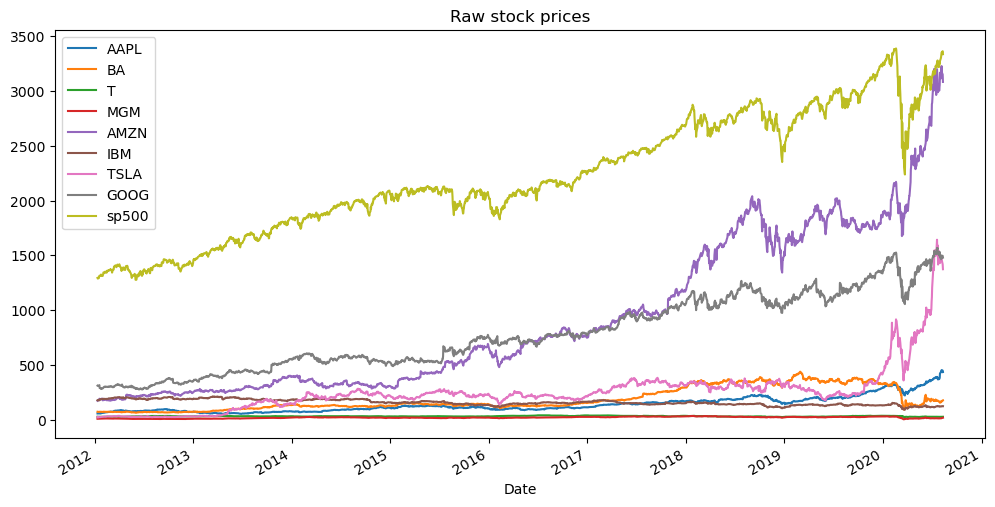

In [16]:
# Plot the raw stock prices
plot_data(df, 'Raw stock prices')

### Task 3
- Define a function to normalize the prices based on the initial price
    - The function simply divides every stock by it’s price at the start date (i.e. : Date = 2012-01-12)

- Plot normalized data

In [17]:
# Define helper functions to select numeric columns and normalize prices by the initial value
def numeric_columns(df):
    '''This function selects the numeric columns of a dataframe.'''
    numeric_cols = df.select_dtypes(include='number').columns
    return numeric_cols

def normalize(df):
    '''Normalizes each numeric column by dividing by its first value.'''
    df = df[numeric_columns(df)]
    return df / df.iloc[0]

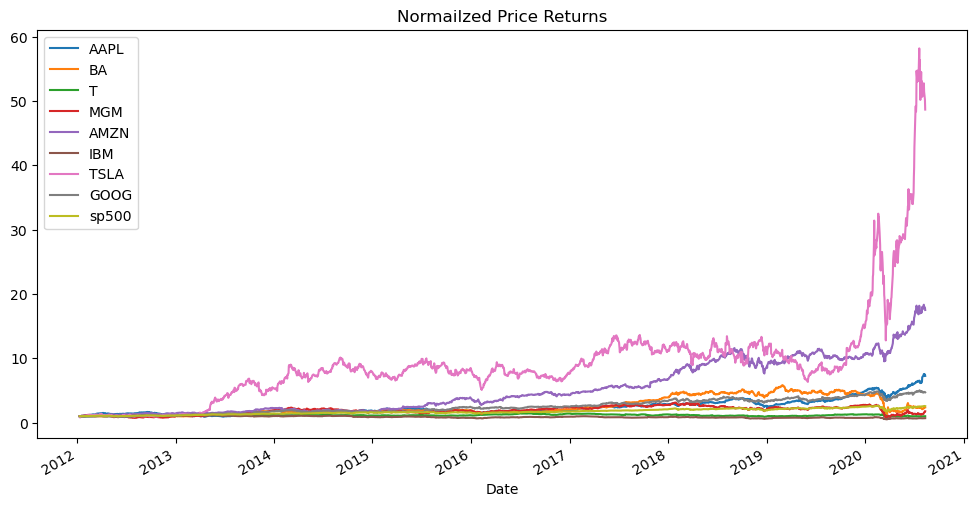

In [18]:
# Plot the normalized stock prices
plot_data( normalize(df), 'Normailzed Price Returns')

### Task 5: Calculate stock returns (1)

- Define a function to calculate stocks daily returns (for all stocks)
    - Loop through each stock
    - Loop through each row belonging to the stock

- Plot it!

In [19]:
# Define the function to compute daily percentage returns
def stock_returns(df):
    '''Computes daily percentage returns for each column.'''
    return df.pct_change().dropna()

In [20]:
# Compute daily returns for all stocks and preview them
df_returns = stock_returns(df)
df_returns.head()

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-13,-0.003749,-0.012051,-0.001660,0.018137,0.014153,-0.007699,-0.193274,-0.007385,-0.004948
2012-01-17,0.011648,0.008579,0.005986,-0.008097,0.018159,0.004689,0.167179,0.005744,0.003553
2012-01-18,0.010384,-0.002392,0.002645,0.039184,0.042827,0.005944,0.007895,0.006889,0.011108
2012-01-19,-0.003169,0.006661,0.002967,0.005499,0.026446,-0.003038,-0.001865,0.010523,0.004939
2012-01-20,-0.017417,-0.000529,0.002959,-0.012500,-0.018102,0.044316,-0.005979,-0.083775,0.000669


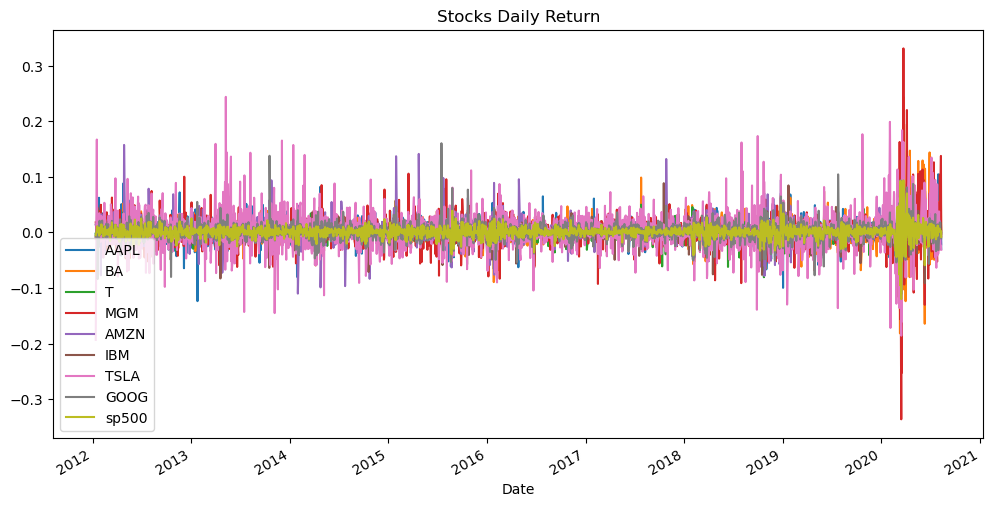

In [21]:
# Plot the daily returns
plot_data(df_returns,'Stocks Daily Return')

### Task #5 : Calculate stock returns (2)

- Calculate the correlations between daily returns

- Plot the correlation table as in heat-map

- What are the top 2 stocks that are positively correlated with the S&P500?

- What is the correlation between Amazon and Boeing? Comment on your answer

- What is the correlation between MGM and Boeing? Comment on your answer

In [22]:
# Define the function to compute the correlation matrix of returns
def correlation(df):
    '''Computes the pairwise correlation matrix of a dataframe.'''
    return df.corr()

In [23]:
# Compute the correlation matrix of daily returns
corr_returns = correlation(df_returns)

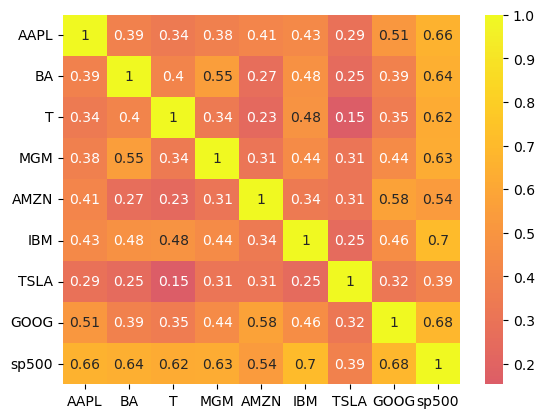

In [59]:
# Plot the correlation matrix as a heatmap
sns.heatmap(corr_returns, cmap='plasma', annot=True, center=0);

In [25]:
# Top 2 stocks most positively correlated with the S&P 500
print(corr_returns['sp500'].drop('sp500').nlargest(2))

IBM     0.703935
GOOG    0.684571
Name: sp500, dtype: float64


In [26]:
# Preview the correlation matrix
corr_returns.head()

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
AAPL,1.000000,0.385249,0.341373,0.384088,0.410233,0.434534,0.288534,0.509124,0.657320
BA,0.385249,1.000000,0.401602,0.554229,0.267466,0.479264,0.250946,0.388048,0.641826
T,0.341373,0.401602,1.000000,0.340166,0.233145,0.484219,0.152515,0.353695,0.617463
MGM,0.384088,0.554229,0.340166,1.000000,0.309016,0.441631,0.311879,0.439141,0.631449
AMZN,0.410233,0.267466,0.233145,0.309016,1.000000,0.339589,0.310083,0.575283,0.539560


In [27]:
# Correlation between Amazon and Boeing
print(f'The correlation between Amazon and Boeing is: {corr_returns.loc['AMZN', 'BA']: .2f}')

The correlation between Amazon and Boeing is:  0.27


*Intuition*: Amazon and Boeing operate in largely different business segments, e-commerce/cloud versus aerospace and defense, so the correlation (0.27) is fairly low. Both are large, widely-held stocks that share some general market beta, but unlike MGM, Amazon has no direct exposure to air-travel demand, so it doesn't share Boeing's pandemic-driven cyclicality.

In [28]:
# Correlation between Boeing and MGM
print(f'The correlation between Boeing and MGM is: {corr_returns.loc['BA', 'MGM']: .2f}')

The correlation between Boeing and MGM is:  0.55


*Intuition*: MGM and Boeing are both downstream of air travel demand, so their returns share a real cyclical driver rather than just market beta. The 2020 travel collapse hit both at once, which inflates the correlation over this particular sample.

### Task #5 : Calculate stock returns (3)

- Plot the histograms of daily returns and comment

- Optional : Define a function to perform an interactive and fancy histograms plots using Plotly module
    - Plotly’s Python API contains a super powerful module known as figure factory

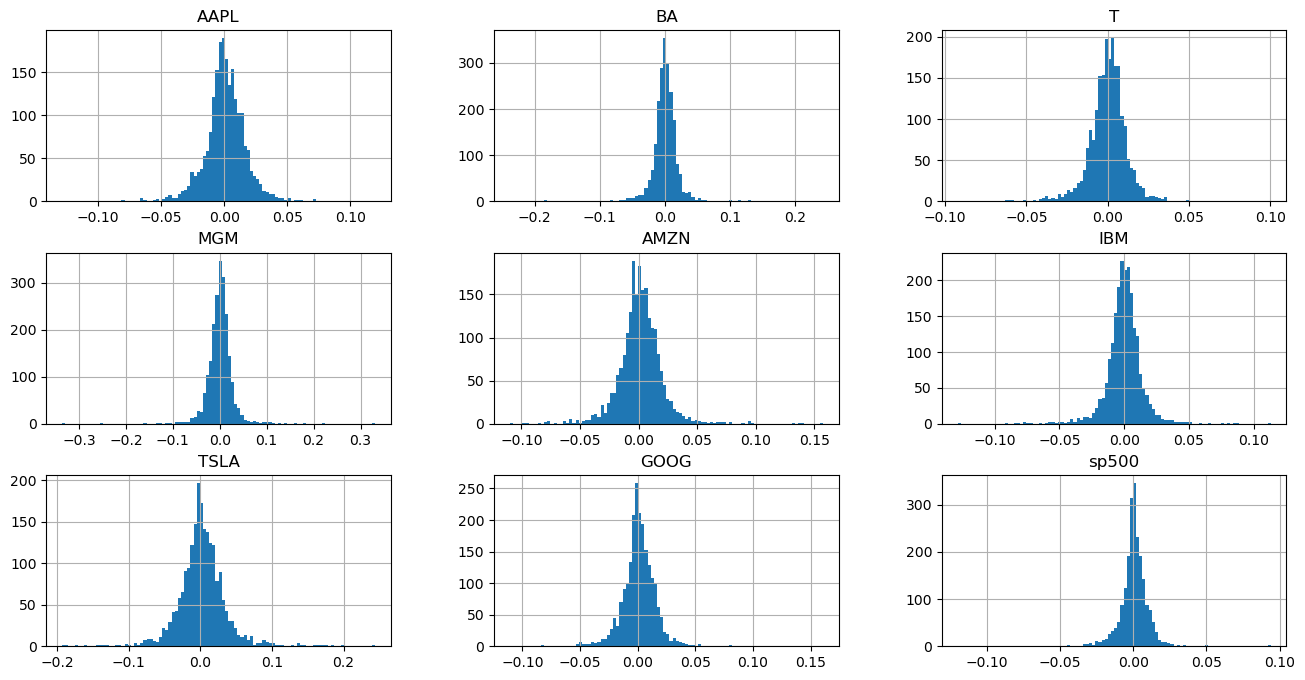

In [29]:
# Plot histograms of daily returns for all stocks
df_returns.hist(bins=100, figsize=(16, 8))
plt.show()

In [30]:
# Skewness and kurtosis of daily returns
display(pd.concat([df_returns.skew(), df_returns.kurt()], axis=1, keys=['skew', 'kurtosis']))

,skew,kurtosis
AAPL,-0.097865,7.319602
BA,0.227336,29.581788
T,-0.497455,9.026663
MGM,0.007458,28.709628
AMZN,0.620135,8.764955
IBM,-0.464064,11.054341
TSLA,0.488056,6.524359
GOOG,0.634918,12.767653
sp500,-0.651611,21.871082


In [31]:
# Define the Jarque-Bera normality test
def jb_test(df):
    '''Jarque-Bera test, computed from raw moments.'''
    n = len(df)
    z = (df - df.mean()) / df.std()
    S = z.skew()
    K = z.kurt()
    JB = n / 6 * (S ** 2 + (K) ** 2 / 4)
    p = np.exp(-JB / 2)
    return pd.DataFrame({'JB': JB, 'p_value': p})

In [32]:
# Run the Jarque-Bera test on daily returns
display(jb_test(df_returns))

,JB,p_value
AAPL,4820.871427,0.0
BA,78703.060430,0.0
T,7415.471299,0.0
MGM,74113.180505,0.0
AMZN,7046.112743,0.0
IBM,11065.134033,0.0
TSLA,3913.177933,0.0
GOOG,14802.571939,0.0
sp500,43163.829836,0.0


*Comment*: None of these returns are normally distributed, and all of them fail the JB test for normality. This matters for what comes next: the mean-variance/Sharpe-ratio framework in Task #6 only uses the first two moments (mean and variance) to rank portfolios, which is only fully justified if returns are normally distributed or investors have quadratic utility. Since returns here are fat-tailed, a portfolio chosen purely to maximize the Sharpe ratio can be exposed to more tail risk than its variance alone suggests. The efficient frontier we build is therefore a useful approximation, not a complete description of risk.


In [33]:
# Define an interactive histogram plot using Plotly
def fancy_hist(df):
    '''Plots an interactive distribution plot of each column using Plotly.'''
    data = [df[col] for col in df.columns]  # necessary to create a list of series, to be able to use the ff plot
    fig = ff.create_distplot(data, list(df.columns), bin_size=0.005)
    fig.show()

In [34]:
# Plot interactive histograms of daily returns
fancy_hist(df_returns)

### Task #6 : Portfolio weights
Simulation exercise : The Empirical Efficient Frontier

- Write a function that will :
    - Simulate 10,000 portfolios with random weights
    - Compute the return, the variance and the SR of each portfolio
    - Return the maximum Sharpe ratio and its weights
- What are the weights of your tangency portfolio? What would have been the performance of this portfolio over the sample period? Plot it!

- *Optional* : Define a function that finds the weights that minimize the variance for all possible level or return (i.e., that draw the efficient frontier). Plot it against the previous scatter plot

In [35]:
# Define the functions to generate historical returns and covar matrix

def annExpRet(df):
    '''Function to calculate the annual expected return, based on historical returns.'''
    return df.mean() * 252

def annCovar(df):
    '''Function to calculate the annual covar matrix, based on historical returns.'''
    return df.cov() * 252

In [36]:
# Create random weight matrix function 

def random_pf_weights(n, s, seed=None):
    '''This function generates n simulations of random weights that sum up to 1 for s numbers of stocks.'''
    df_weights = np.random.rand(n, s)
    return df_weights / df_weights.sum(axis=1, keepdims=True) # keeps the (n, 1) shape

In [37]:
# Define portfolio return, variance and Sharpe ratio functions

def p_returns(mu, w):
    '''Calculates portfolio returns.'''
    return w @ mu

def p_var(cov, w):
    '''Function calculates the portfolio variance.'''
    return (w @ cov * w).sum(axis=1) # sum(axis=1) to get scalar per pf

def SR(Er, Var):
    '''Calculates the SR of a given Er to Var relation.'''
    return Er / (Var ** 0.5)

In [38]:
# Exclude the S&P 500 index from the investable universe (used only as benchmark)
df_stocks_returns = df_returns.drop(columns='sp500')
df_stocks_returns.shape

(2158, 8)

In [39]:
# Annualised expected returns and covariance matrix for the full sample
mu = annExpRet(df_stocks_returns)
cov = annCovar(df_stocks_returns)

In [40]:
# Simulate 10,000 random portfolios across the 8 stocks
sim_weights = random_pf_weights(10000, 8, seed=5)

In [41]:
# Compute return, variance and Sharpe ratio for each simulated portfolio
er_p = p_returns(mu, sim_weights)    
var_p = p_var(cov, sim_weights)
sr_p = SR(er_p, var_p)

In [42]:
# Extract the maximum Sharpe ratio and its corresponding weights
best_sr = sr_p.max()
best_sr_weights = pd.Series(sim_weights[sr_p.idxmax()], index=df_stocks_returns.columns)

print(f'The maximum SR for the portfolio is: {best_sr:.4f}\nWith the weights of:\n{best_sr_weights}')

The maximum SR for the portfolio is: 1.3971
With the weights of:
AAPL    0.129224
BA      0.024011
T       0.014993
MGM     0.002357
AMZN    0.321358
IBM     0.038660
TSLA    0.196370
GOOG    0.273027
dtype: float64


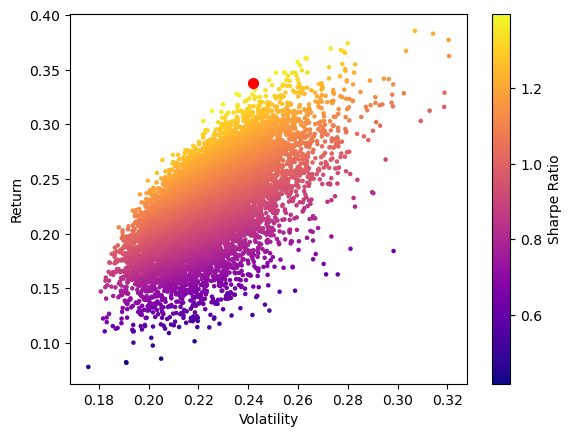

In [43]:
# Plot the simulated portfolios
plt.scatter((var_p ** 0.5), er_p, c=sr_p, cmap='plasma', s=5)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(var_p[sr_p.idxmax()] ** 0.5, er_p[sr_p.idxmax()], color='red', s=50)
plt.xlabel('Volatility')
plt.ylabel('Return');

In [44]:
# Define the function to find minimum-variance weights
def min_var_weights(mu, cov, target):
    '''Weights minimising variance for a given target return, no shorting.'''
    n = len(mu)
    cons = [
        {'type': 'eq', 'fun': lambda w: w.sum() - 1},
        {'type': 'eq', 'fun': lambda w: w @ mu - target},
    ]
    bounds = [(0, 1)] * n
    start = np.repeat(1 / n, n)
    res = minimize(lambda w: w @ cov @ w, start, bounds=bounds, constraints=cons)
    return res.x

In [45]:
# Trace the efficient frontier by minimising variance 
targets = np.linspace(er_p.min(), er_p.max(), 50)
front_vol = [np.sqrt(min_var_weights(mu, cov, t) @ cov @ min_var_weights(mu, cov, t)) for t in targets]

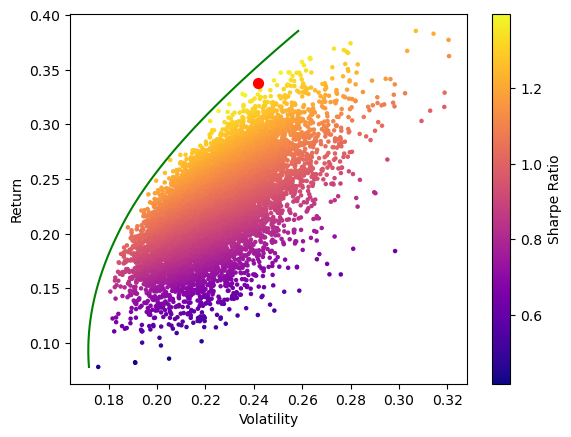

In [46]:
# Plot the simulated portfolios together with the efficient frontier
plt.scatter((var_p ** 0.5), er_p, c=sr_p, cmap='plasma', s=5)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(var_p[sr_p.idxmax()] ** 0.5, er_p[sr_p.idxmax()], color='red', s=50)
plt.xlabel('Volatility')
plt.ylabel('Return');
plt.plot(front_vol, targets, color='green');

In [47]:
# Cumulative performance of the tangency portfolio vs. equal-weight vs. S&P 500
best_sr_daily_returns = df_stocks_returns @ best_sr_weights
cum_port = (1 + best_sr_daily_returns).cumprod()

cum_spx = (1 + df_returns['sp500']).cumprod()

ew_weights = pd.Series(1 / 8, index=df_stocks_returns.columns)
cum_ew = (1 + df_stocks_returns @ ew_weights).cumprod()

# Same starting point for all 3 strategies, with one unit

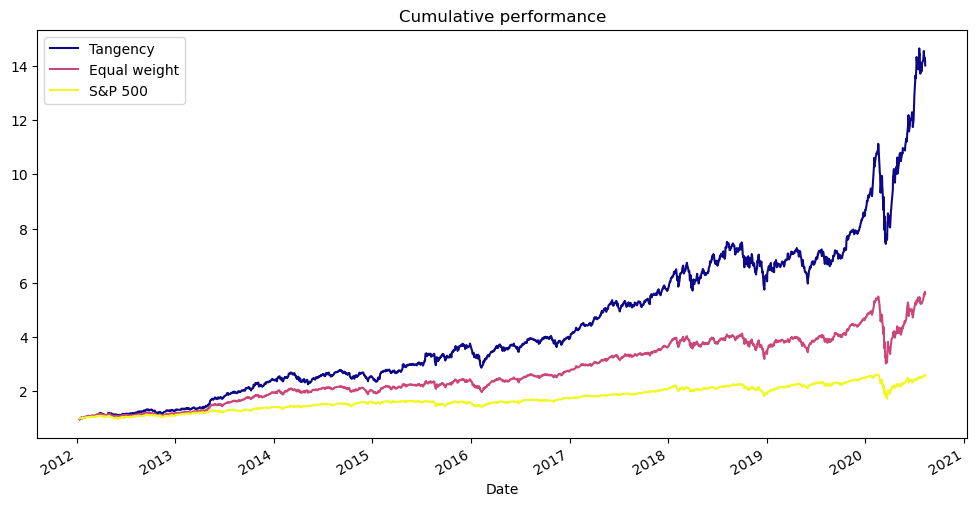

In [48]:
# Plot cumulative performance of the tangency, equal-weight and S&P 500 strategies
cum_all = pd.concat([cum_port, cum_ew, cum_spx], axis=1, keys=['Tangency', 'Equal weight', 'S&P 500'])
cum_all.plot(figsize=(12, 6), title='Cumulative performance', colormap='plasma');

### Task #7 : Testing Portfolio Theory
- Re-run Task #6 but only on the first part of the sample (2012-2016)
- Find out what are the optimal weights for this period
- Simulate your optimal portfolio on the second part of the sample (2016-end)
    - How does it perform?
    - Plot the expected (measured over the 1st period) vs. the realized return andvolatility (over the second).
- Optional : Let’s go a step further. Every year, you re-balance your portfolio based on last year data (ie., you create a new Markowitz portfolio every year). What is your performance overall? Comment.

In [49]:
# Split sample in training and test period
train = df_stocks_returns.loc[:'2015-12-31']
test = df_stocks_returns.loc['2016-01-01':]

# Re-estimate expected returns and covariance using only the training period
mu_train = annExpRet(train)
cov_train = annCovar(train)

w_train = random_pf_weights(10000, 8, seed=5)

er_p_train = p_returns(mu_train, w_train)
var_p_train = p_var(cov_train, w_train)
sr_train = SR(er_p_train, var_p_train)

In [50]:
# Extract the maximum Sharpe ratio and weights for the training period
best_sr_train = sr_train.max()
best_sr_train_weights = pd.Series(w_train[sr_train.idxmax()], index=train.columns)

print(f'The maximum SR in the training period is: {best_sr_train:.4f}\nWith the weights of:\n{best_sr_train_weights}')

The maximum SR in the training period is: 1.6707
With the weights of:
AAPL    0.063010
BA      0.284634
T       0.013302
MGM     0.001774
AMZN    0.324208
IBM     0.004412
TSLA    0.188096
GOOG    0.120564
dtype: float64


In [51]:
# Apply the training-period tangency weights to the test period (out-of-sample)
best_sr_train_daily_returns = test @ best_sr_train_weights
cum_port_test = (1 + best_sr_train_daily_returns).cumprod()

cum_spx_test = (1 + df_returns.loc['2016-01-01':,'sp500']).cumprod()

cum_ew_test = (1 + test @ ew_weights).cumprod()

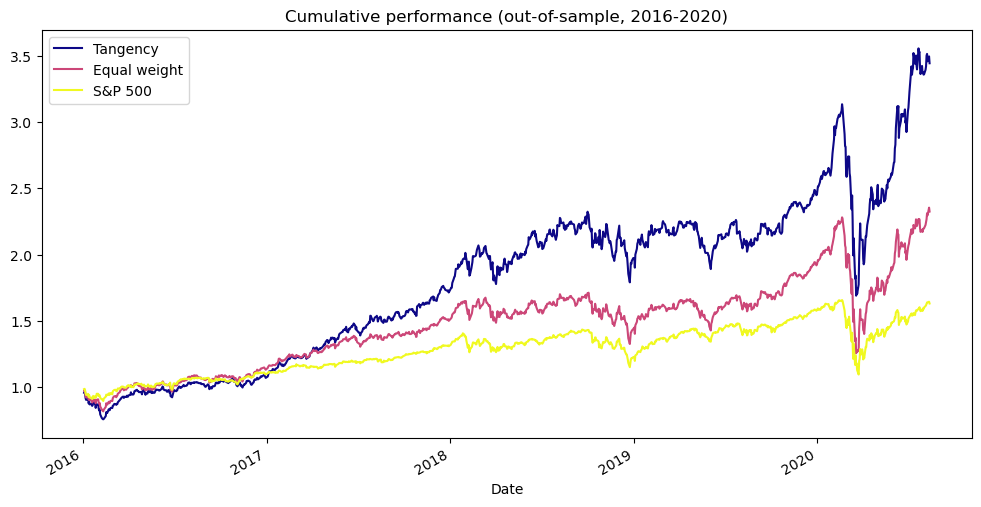

In [52]:
# Plot the out-of-sample cumulative performance of tangency, equal-weight and S&P 500
cum_test = pd.concat([cum_port_test, cum_ew_test, cum_spx_test], axis=1, keys=['Tangency', 'Equal weight', 'S&P 500'])
cum_test.plot(figsize=(12, 6), title='Cumulative performance (out-of-sample, 2016-2020)', colormap='plasma');

In [53]:
# Compare expected (in-sample) vs realised (out-of-sample) performance
best_w = sr_train.idxmax()
exp_ret = er_p_train[best_w]
exp_vol = var_p_train[best_w] ** 0.5
exp_SR = exp_ret / exp_vol

real_ret = best_sr_train_daily_returns.mean() * 252
real_vol = best_sr_train_daily_returns.std() * 252 ** 0.5
real_SR = real_ret / real_vol

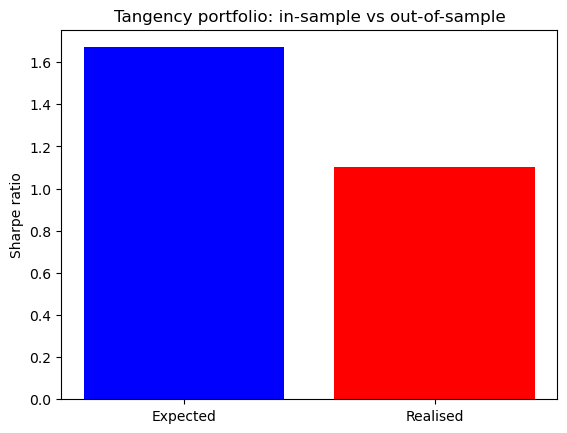

In [54]:
# Compare expected (in-sample) vs realised (out-of-sample) Sharpe ratio
plt.bar(['Expected', 'Realised'], [exp_SR, real_SR], color=['blue', 'red'])
plt.ylabel('Sharpe ratio')
plt.title('Tangency portfolio: in-sample vs out-of-sample');

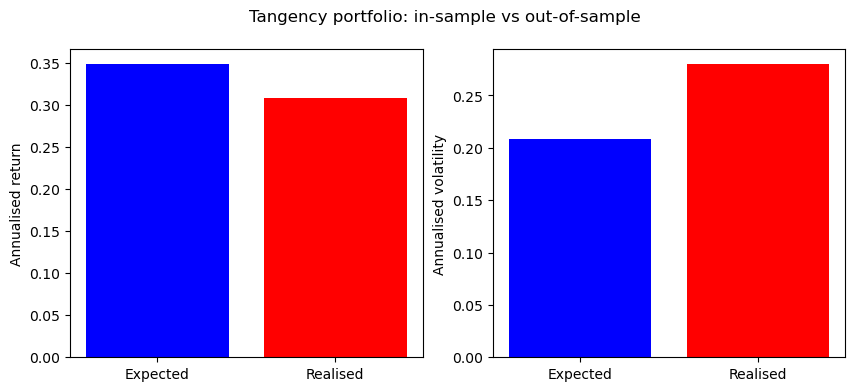

In [55]:
# Compare expected vs realised return and volatility
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Expected', 'Realised'], [exp_ret, real_ret], color=['blue', 'red'])
axes[0].set_ylabel('Annualised return')
axes[1].bar(['Expected', 'Realised'], [exp_vol, real_vol], color=['blue', 'red'])
axes[1].set_ylabel('Annualised volatility')
fig.suptitle('Tangency portfolio: in-sample vs out-of-sample');

*Comment*: The tangency portfolio estimated on the training period (2012-2015) performs well out-of-sample: $1 invested at the start of 2016 grows to about $3.77 by the end of the sample, versus about $2.33 for equal-weight and $1.63 for the S&P 500 over the same window. As expected, the realised Sharpe ratio (1.18) is lower than the in-sample expected Sharpe ratio (1.67). The optimiser partly overfits the training-period mean and covariance estimates, so some of that in-sample performance doesn't carry over, but the tangency portfolio still clearly beats both benchmarks out-of-sample here.

In [56]:
# Define the function to re-optimise the tangency portfolio every year using only the previous year's data
def yearly_rebalancing(df, n=10000, seed=5):
    '''This function rebalances a Markowitz portfolio every year, based on the previous year data.'''
    years = df.index.year.unique()
    returns_list = []
    weights_list = []

    for y in years[1:]:
        estimation = df.loc[str(y - 1)]
        holding = df.loc[str(y)]

        mu = annExpRet(estimation)
        cov = annCovar(estimation)

        w = random_pf_weights(n, df.shape[1], seed=seed)
        sr = SR(p_returns(mu, w), p_var(cov, w))
        best_w = w[sr.idxmax()]

        returns_list.append(holding @ best_w)
        weights_list.append(pd.Series(best_w, index=df.columns, name=y))

    return pd.concat(returns_list), pd.concat(weights_list, axis=1).T

In [57]:
# Apply yearly-rebalanced Markowitz strategy over the full sample
rebal_returns, rebal_weights = yearly_rebalancing(df_stocks_returns)
cum_rebal = (1 + rebal_returns).cumprod()

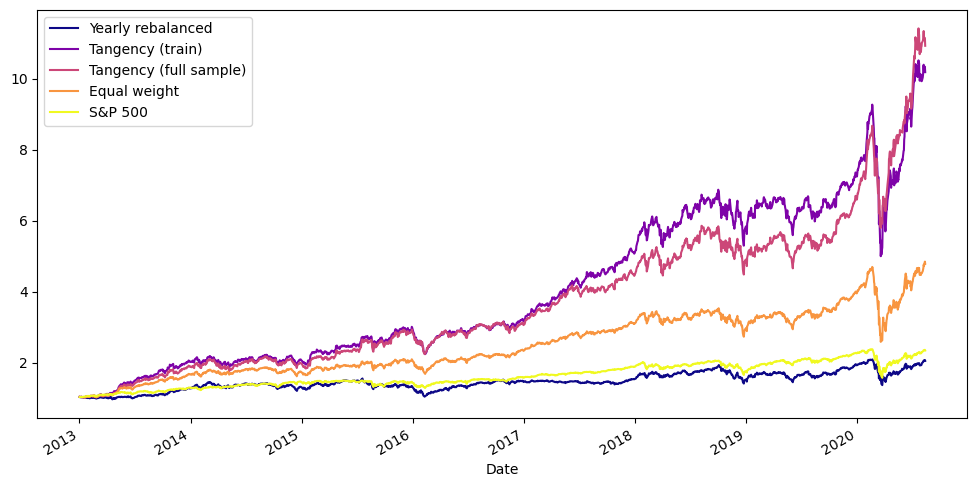

In [58]:
# Compare yearly-rebalanced strategy against static benchmarks
start = rebal_returns.index[0]
sub = df_stocks_returns.loc[start:]

comp = pd.concat([
    (1 + rebal_returns).cumprod(),
    (1 + sub @ best_sr_train_weights).cumprod(),
    (1 + sub @ best_sr_weights).cumprod(),
    (1 + sub @ ew_weights).cumprod(),
    (1 + df_returns.loc[start:, 'sp500']).cumprod()
], axis=1, keys=['Yearly rebalanced', 'Tangency (train)', 'Tangency (full sample)', 'Equal weight', 'S&P 500'])

comp.plot(figsize=(12, 6), colormap='plasma');

*Comment*: Over 2013-2020, the yearly-rebalanced Markowitz portfolio actually underperforms both static tangency portfolios and even trails the simple equal-weight benchmark, though it still beats the S&P 500. Re-estimating the "optimal" weights every year from only the trailing 12 months of returns means each year's weights are highly sensitive to estimation error in that short window, so the strategy ends up chasing whichever stock had the best trailing Sharpe ratio rather than holding a stable, diversified position. The static portfolios, by contrast, happened to load heavily on AMZN and TSLA early on and simply rode that concentrated bet for the rest of the sample. This illustrates the classic critique of naive mean-variance optimisation: in-sample "optimal" weights are unstable, and frequent re-optimisation on short windows can make things worse rather than better.